In [17]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from utils import geometric_multiclass_margins, multiclass_functional_margins, project_to_hyperplane

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Generate 3-class, 2D dataset
def make_3class_data(n_per_class=1, means=None, std=0.0):
    if means is None:
        means = [(-1, -1), (1, -1), (0, 1)]
    X = []
    y = []
    for i, mu in enumerate(means):
        Xi = np.random.randn(n_per_class, 2) * std + np.array(mu)
        yi = np.full(n_per_class, i)
        X.append(Xi)
        y.append(yi)
    X = np.vstack(X)
    y = np.concatenate(y)
    return X.astype(np.float32), y.astype(np.int64)

X, y = make_3class_data()

# Prepare Data for PyTorch
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y)

# Define a deep linear network (Linear -> ReLU (optional) -> Linear)
class DeepLinearNet(nn.Module):
    def __init__(self, d_in=2, d_hidden=10, d_out=3, depth=10):
        super().__init__()
        if depth > 1:
            layers = []
            # Input layer
            layers.append(nn.Linear(d_in, d_hidden, bias=True))
            # Hidden layers (all linear)
            for _ in range(depth-1):
                layers.append(nn.Linear(d_hidden, d_hidden, bias=True))
            # Output layer
            layers.append(nn.Linear(d_hidden, d_out, bias=True))
        else:
            layers = [nn.Linear(d_in, d_out, bias=True)]
        self.layers = nn.ModuleList(layers)
    
    def forward(self, x):
        for l in self.layers[:-1]:
            x = l(x)
        x = self.layers[-1](x)
        return x

def train_model(X_tensor, y_tensor, depth, n_epochs=100, lr=0.1, seed=42, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = DeepLinearNet(d_in=2, d_hidden=10, d_out=3, depth=depth)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_l, acc_l = [], []
    for epoch in tqdm(range(n_epochs), desc=f'depth={depth}', leave=False):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
        loss_l.append(loss.item())
        acc_l.append((outputs.argmax(dim=1) == y_tensor).float().mean().item())
        if verbose and (epoch + 1) % 10 == 0:
            print(f"depth={depth} epoch={epoch+1}, loss={loss.item():.4f}, acc={acc_l[-1]*100:.1f}%")
    return model, loss_l, acc_l


def effective_affine(model):
    """Compose a deep linear net into scores = x @ W + b."""
    W = model.layers[0].weight.detach().cpu().numpy().T
    b = model.layers[0].bias.detach().cpu().numpy()
    for layer in model.layers[1:]:
        W = W @ layer.weight.detach().cpu().numpy().T
        b = b @ layer.weight.detach().cpu().numpy().T + layer.bias.detach().cpu().numpy()
    return W, b


def compute_all_margins(W, b, X, y, net_depth):
    geom_margins, geom_hardest = geometric_multiclass_margins(W, X, y, b=b)
    l2_margins, l2_hardest = multiclass_functional_margins(
        W, X, y, b=b, normalize=False, normalization='l2',
    )
    schatten_margins, schatten_hardest = multiclass_functional_margins(
        W, X, y, b=b, normalize=False, normalization='schatten', L=net_depth,
    )
    return {
        'geometric': (geom_margins, geom_hardest),
        'l2': (l2_margins, l2_hardest),
        'schatten': (schatten_margins, schatten_hardest),
    }


def draw_decision_map(ax, W, b, X, y, x_lim, y_lim, steps=200):
    xx, yy = np.meshgrid(
        np.linspace(x_lim[0], x_lim[1], steps),
        np.linspace(y_lim[0], y_lim[1], steps),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    scores = grid @ W + b
    Z = scores.argmax(axis=1).reshape(xx.shape)

    n_classes = W.shape[1]
    ax.contourf(xx, yy, Z, alpha=0.2, levels=np.arange(n_classes + 1) - 0.5, cmap=plt.cm.brg)
    colors = ['r', 'g', 'b']
    for i in range(n_classes):
        ax.scatter(X[y == i, 0], X[y == i, 1], color=colors[i], s=80, zorder=3, label=f'class {i}')

    xs = np.linspace(x_lim[0], x_lim[1], 300)
    for k1 in range(n_classes):
        for k2 in range(k1 + 1, n_classes):
            w_diff = W[:, k1] - W[:, k2]
            b_diff = b[k1] - b[k2]
            if abs(w_diff[1]) > 1e-8:
                ys = -(w_diff[0] * xs + b_diff) / w_diff[1]
                ax.plot(xs, ys, 'k--', lw=1, alpha=0.7, zorder=1)


def draw_margin_segments(ax, W, b, X, y, margins, hardest_k, min_idx, title):
    for i, (x, label, k, margin) in enumerate(zip(X, y, hardest_k, margins)):
        w_diff = W[:, label] - W[:, k]
        b_diff = b[label] - b[k]
        foot = project_to_hyperplane(x, w_diff, b_diff)
        color = '0.75' if i != min_idx else 'crimson'
        lw = 1 if i != min_idx else 2.5
        zorder = 2 if i != min_idx else 4
        ax.plot([x[0], foot[0]], [x[1], foot[1]], color=color, lw=lw, zorder=zorder)
        if i == min_idx:
            ax.scatter(x[0], x[1], s=140, facecolors='none', edgecolors='crimson', linewidths=2, zorder=5)
            ax.annotate(
                f'min={margin:.3f}',
                xy=x,
                xytext=(8, 8),
                textcoords='offset points',
                color='crimson',
                fontsize=10,
            )
    ax.set_title(title)
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')


def plot_decision_boundary(model, X, y, steps=300):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, steps),
        np.linspace(y_min, y_max, steps),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    with torch.no_grad():
        Z = model(torch.from_numpy(grid)).argmax(dim=1).numpy().reshape(xx.shape)

    W_eff, b_eff = effective_affine(model)
    n_classes = W_eff.shape[1]

    plt.figure(figsize=(7, 7))
    plt.contourf(xx, yy, Z, alpha=0.25, levels=np.arange(n_classes + 1) - 0.5, cmap=plt.cm.brg)
    for i, c in enumerate(['r', 'g', 'b']):
        plt.scatter(X[y == i, 0], X[y == i, 1], label=f"Class {i}", color=c)

    xs = np.linspace(x_min, x_max, 500)
    for k1 in range(n_classes):
        for k2 in range(k1 + 1, n_classes):
            w_diff = W_eff[:, k1] - W_eff[:, k2]
            b_diff = b_eff[k1] - b_eff[k2]
            if abs(w_diff[1]) > 1e-6:
                ys = -(w_diff[0] * xs + b_diff) / w_diff[1]
                plt.plot(xs, ys, 'k--', lw=1)

    plt.legend()
    plt.title("Deep Linear Network: Decision Areas and Boundaries")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()



=== depth=1 (net_depth=0) ===
geometric: min=0.8990 at point 2 (class 2)
l2: min=0.8868 at point 1 (class 1)
schatten: min=0.8868 at point 1 (class 1)



=== depth=2 (net_depth=2) ===
geometric: min=0.9954 at point 1 (class 1)
l2: min=0.9870 at point 2 (class 2)
schatten: min=0.6995 at point 2 (class 2)



=== depth=3 (net_depth=3) ===
geometric: min=0.9454 at point 1 (class 1)
l2: min=0.7325 at point 2 (class 2)
schatten: min=0.4084 at point 2 (class 2)



=== depth=4 (net_depth=4) ===
geometric: min=0.7912 at point 0 (class 0)
l2: min=0.5755 at point 0 (class 0)
schatten: min=0.2732 at point 0 (class 0)



=== depth=5 (net_depth=5) ===
geometric: min=0.5053 at point 0 (class 0)
l2: min=0.3628 at point 0 (class 0)
schatten: min=0.1782 at point 0 (class 0)


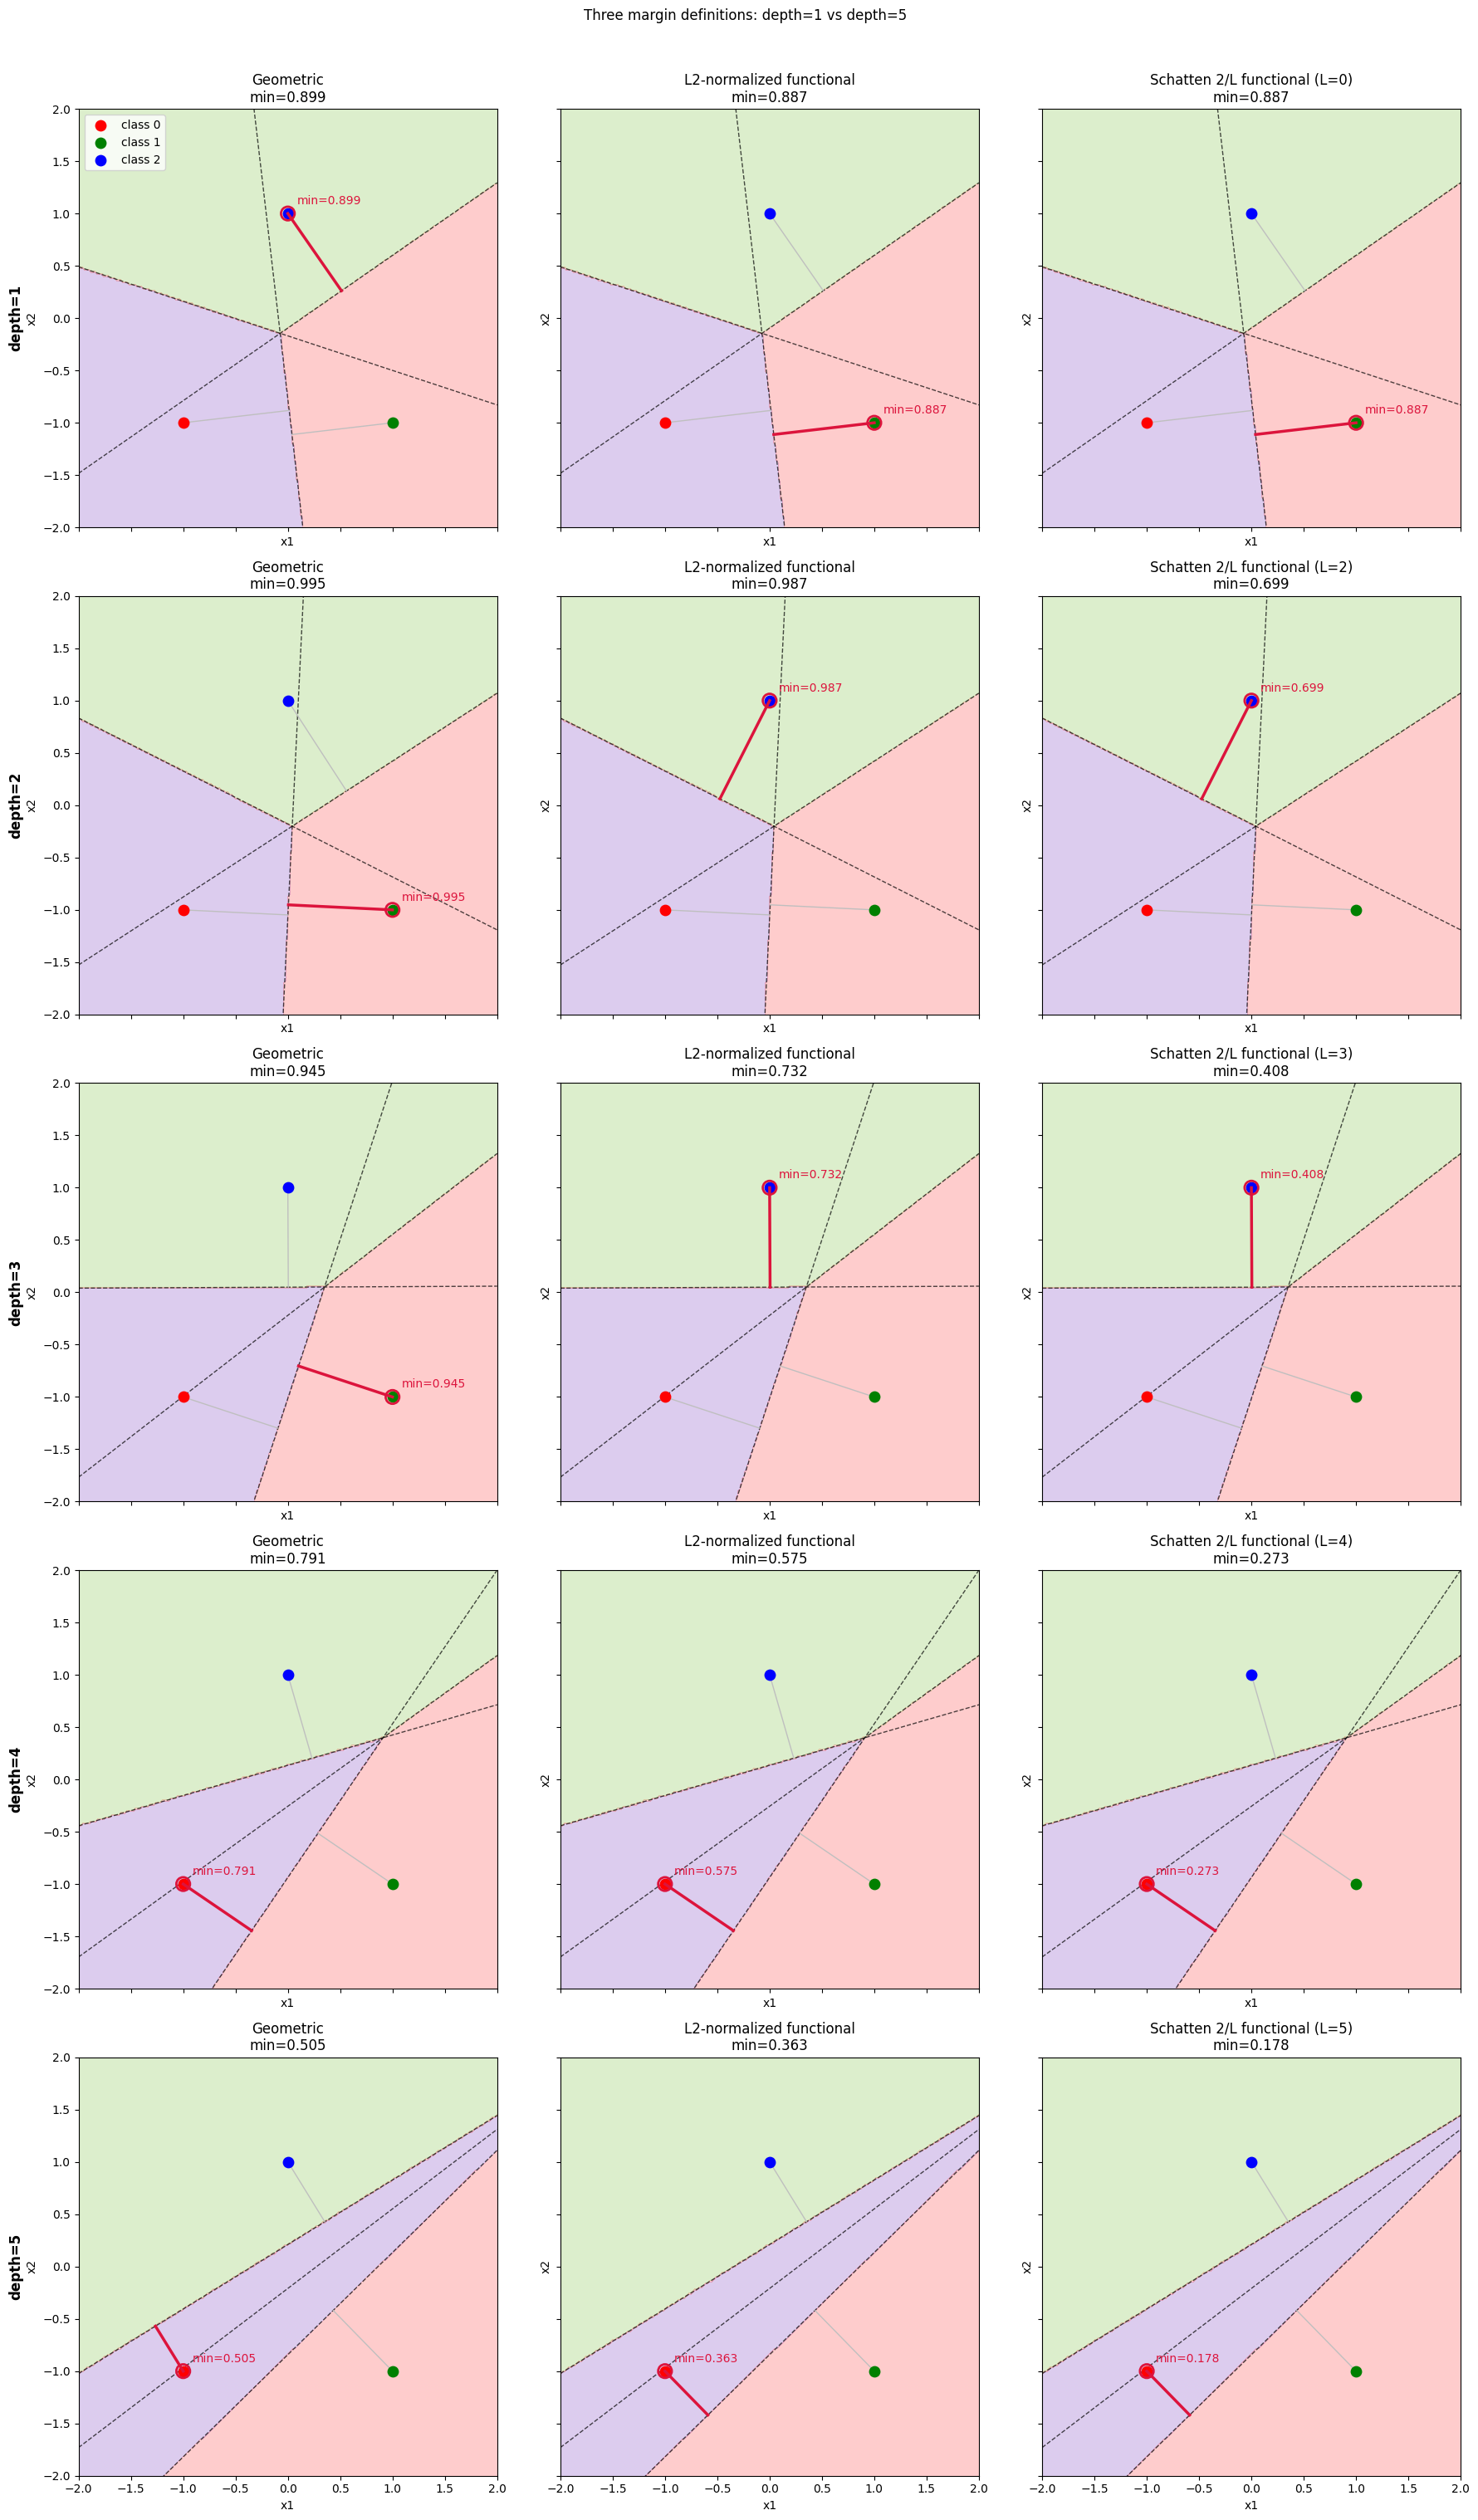

In [18]:
depths = np.arange(1,6)
n_epochs = 100
seed = 1
results = {}

x_lim = (X[:, 0].min() - 1, X[:, 0].max() + 1)
y_lim = (X[:, 1].min() - 1, X[:, 1].max() + 1)

fig, axs = plt.subplots(len(depths), 3, figsize=(18, 6 * len(depths)), sharex=True, sharey=True)

for row, depth in enumerate(depths):
    model, loss_l, acc_l = train_model(X_tensor, y_tensor, depth=depth, n_epochs=n_epochs, seed=seed)
    W_eff, b_eff = effective_affine(model)
    net_depth = len(model.layers) - 1
    margins = compute_all_margins(W_eff, b_eff, X, y, net_depth)
    results[depth] = {'model': model, 'W': W_eff, 'b': b_eff, 'margins': margins, 'loss_l': loss_l, 'acc_l': acc_l}

    print(f'\n=== depth={depth} (net_depth={net_depth}) ===')
    for name, (vals, _) in margins.items():
        idx = vals.argmin()
        print(f'{name}: min={vals.min():.4f} at point {idx} (class {y[idx]})')

    panels = [
        (margins['geometric'], f'Geometric\nmin={margins["geometric"][0].min():.3f}'),
        (margins['l2'], f'L2-normalized functional\nmin={margins["l2"][0].min():.3f}'),
        (margins['schatten'], f'Schatten 2/L functional (L={net_depth})\nmin={margins["schatten"][0].min():.3f}'),
    ]
    for col, ((vals, hardest), title) in enumerate(panels):
        ax = axs[row, col]
        draw_decision_map(ax, W_eff, b_eff, X, y, x_lim, y_lim)
        draw_margin_segments(ax, W_eff, b_eff, X, y, vals, hardest, vals.argmin(), title)
        ax.set_xlim(x_lim)
        ax.set_ylim(y_lim)
        ax.set_aspect('equal')
        if col == 0:
            ax.text(
                x_lim[0] - 0.15 * (x_lim[1] - x_lim[0]), np.mean(y_lim),
                f'depth={depth}',
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold',
            )
        if row == 0 and col == 0:
            ax.legend(loc='upper left')

fig.suptitle('Three margin definitions: depth=1 vs depth=5', y=1.01)
plt.tight_layout()
plt.show()

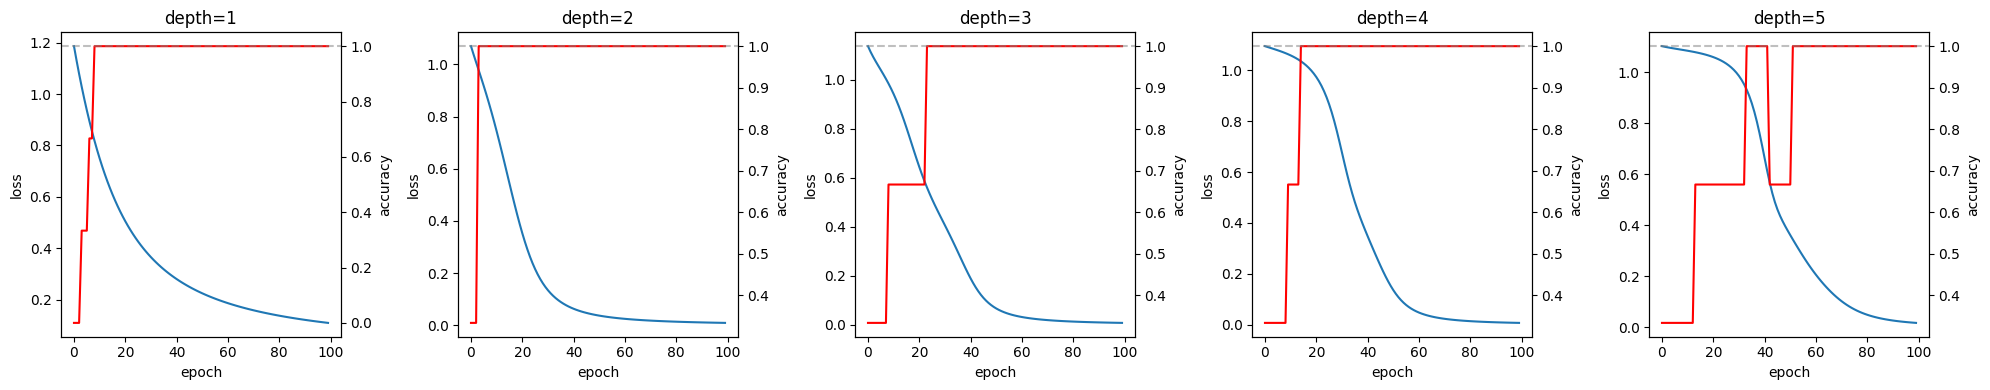

In [19]:
fig, axs = plt.subplots(1, len(depths), figsize=(len(depths)*4, 4))
for ax, depth in zip(axs, depths):
    ax.plot(results[depth]['loss_l'], label='loss')
    ax2 = ax.twinx()
    ax2.plot(results[depth]['acc_l'], 'r', label='acc')
    ax.set_title(f'depth={depth}')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax2.set_ylabel('accuracy')
    ax2.axhline(1.0, color='gray', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

rows = []
for depth in depths:
    margins = results[depth]['margins']
    for i in range(len(y)):
        rows.append({
            'depth': depth,
            'point': i,
            'class': y[i],
            'geometric': margins['geometric'][0][i],
            'l2': margins['l2'][0][i],
            'schatten': margins['schatten'][0][i],
        })

pd.DataFrame(rows)

,depth,point,class,geometric,l2,schatten
0,1,0,0,1.019681,0.935225,0.935225
1,1,1,1,0.966849,0.886769,0.886769
2,1,2,2,0.899000,0.935896,0.935896
3,2,0,0,1.002292,1.002023,0.710127
4,2,1,1,0.995375,0.995108,0.705226
5,2,2,2,1.029683,0.987012,0.699489
6,3,0,0,0.954151,0.798349,0.445109
7,3,1,1,0.945422,0.791046,0.441037
8,3,2,2,0.950601,0.732466,0.408377
9,4,0,0,0.791161,0.575471,0.273158


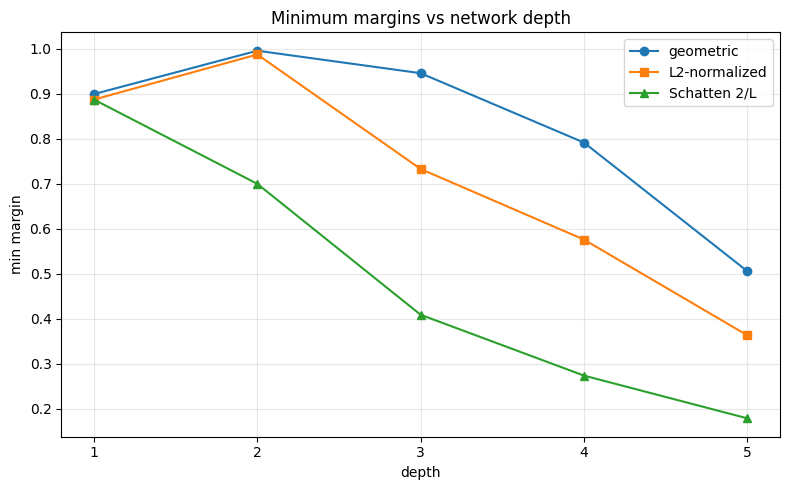

In [21]:
depth_values = sorted(results.keys())
min_margins = {name: [] for name in ['geometric', 'l2', 'schatten']}
for depth in depth_values:
    margins = results[depth]['margins']
    for name in min_margins:
        min_margins[name].append(margins[name][0].min())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depth_values, min_margins['geometric'], 'o-', label='geometric')
ax.plot(depth_values, min_margins['l2'], 's-', label='L2-normalized')
ax.plot(depth_values, min_margins['schatten'], '^-', label='Schatten 2/L')
ax.set_xlabel('depth')
ax.set_ylabel('min margin')
ax.set_title('Minimum margins vs network depth')
ax.set_xticks(depth_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()